# Module 5: Deep Learning Models for Cybersecurity

---

## Learning Objectives

By the end of this module, you will be able to:

* **Explain when deep learning earns its cost.** Articulate why neural networks outperform classical ML on high-dimensional, unstructured, or sequential security data — and identify the cases where a Random Forest is still the better engineering choice.
* **Prepare data for neural networks.** Represent security data as tensors, apply the correct scaling strategy for gradient-based learning, and encode categorical fields such as protocol and alert type.
* **Detect fraud with an Autoencoder.** Train a network on normal behavior only, score anomalies by reconstruction error, and explain why contaminating the training set defeats the method entirely.
* **Tune a decision threshold deliberately.** Use precision-recall curves to select an operating point, and explain why the default 0.5 cutoff is almost always the wrong choice on imbalanced security data.
* **Build and tune a Multi-Layer Perceptron.** Reason about depth, width, dropout, and activation functions, and diagnose underfitting versus overfitting from training curves.
* **Classify malware without executing it.** Treat compiled binaries as grayscale images and train a 2D CNN to sort samples into malware families.
* **Model sequences two ways.** Compare 1D CNNs against LSTMs for character-level DGA detection, and justify which belongs in a high-throughput SOC pipeline.
* **Apply deep learning to email text.** Tokenize and embed natural language to detect phishing, and recognize when a model has learned sender reputation instead of phishing behavior.
* **Audit your own evaluation.** Identify data leakage in a training pipeline, quantify how much it inflates your metrics, and correct the split.

---

## Introduction to Deep Learning in Security

As cyber threats become increasingly sophisticated, traditional signature-based detection and standard machine learning techniques often struggle to keep pace. This is where **Deep Learning (DL)** steps in. Deep Learning, a subset of machine learning inspired by the structure and function of the human brain (artificial neural networks), excels at finding hidden patterns in massive, complex, and unstructured datasets.

### Why Deep Learning?

* **Feature Extraction:** Unlike traditional ML, which requires painstaking manual feature engineering, DL models can automatically learn and extract the most relevant features directly from raw data (e.g., raw network packets, binary files, or system logs).
* **Handling Complexity:** DL models thrive on high-dimensional data, making them perfect for analyzing complex network traffic patterns or analyzing the chaotic behavior of modern malware.
* **Adaptability:** Deep neural networks can generalize better to unseen, zero-day attacks by understanding underlying malicious behaviors rather than just matching known signatures.

### Key Examples of Deep Learning in Cybersecurity

1. **Advanced Malware Detection:** Deep neural networks (like Convolutional Neural Networks, or CNNs) can treat compiled binaries almost like images, scanning the raw bytes to detect malicious patterns without ever executing the code or relying on known hash signatures.
2. **Network Intrusion Detection Systems (NIDS):** Recurrent Neural Networks (RNNs) and Long Short-Term Memory (LSTM) networks are incredibly effective at analyzing time-series data. They can monitor network traffic over time to identify subtle, anomalous sequences that indicate a stealthy intrusion or Advanced Persistent Threat (APT).
3. **Phishing and Malicious URL Detection:** Natural Language Processing (NLP) models powered by deep learning can analyze the structure, semantics, and context of emails and URLs to spot incredibly convincing phishing attempts that trick standard spam filters.
4. **User and Entity Behavior Analytics (UEBA):** Autoencoders can learn the 'normal' baseline behavior for every user on a network. If an attacker compromises an account and starts acting unusually (e.g., accessing databases they normally don't touch), the deep learning model flags the anomaly immediately.

In [ ]:
# ============================================================
# Module 5 Setup -- run this cell first, every session.
# ============================================================
# Deep learning is stochastic: weights start random, dropout drops
# random neurons, and data is shuffled randomly. Without a fixed seed
# you would get different numbers every run and could never tell a
# real improvement from luck. Reproducibility is a research skill,
# not a formality.

import os, random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Where this course hosts its datasets
DATA_URL = "https://github.com/abramweigant/AI-Cyber-Intro-Cert/raw/refs/heads/main/"

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {bool(tf.config.list_physical_devices('GPU'))}")
print(f"Random seed fixed at {SEED}")

# NOTE: Enable the GPU before running the training cells:
#   Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU -> Save


### Deep Learning in Action: Fraud Detection

In the previous module, you likely explored unsupervised learning methods (like Isolation Forest or K-Means) to detect anomalies in this credit card dataset. While those methods are great when you don't have labeled data, Deep Learning via an **Autoencoder** can often achieve much higher accuracy by learning complex representations of normal data and flagging deviations.

Here, we will build an **Autoencoder** using TensorFlow and Keras to detect fraudulent transactions based on reconstruction error. We will:
1. Preprocess and scale the data.
2. Build an Autoencoder model.
3. Train the model and evaluate its performance.

## **Important:**
* Enable T4 GPU: Down arrow in top right corner -> Change runtime type -> Select: T4 GPU -> Save.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The URL to the zipped CSV file
url = DATA_URL + "creditcard.csv.zip"

# Load the dataset directly from the ZIP file
print(f"Downloading and loading data from: {url}...")
df = pd.read_csv(url, compression='zip')

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape} (rows, columns)")

# Display the first 5 rows
display(df.head())

Dataset loaded successfully!
Dataset shape: (284807, 31) (rows, columns)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
import numpy as np

# The 'Class' column is our label (0 = Normal, 1 = Fraud)
X = df.drop('Class', axis=1)
y = df['Class']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Suppress SettingWithCopyWarning for cleaner output
warnings.filterwarnings('ignore')

# Create copies so we don't alter the original split data directly
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Initialize the scaler
scaler = StandardScaler()

# The only columns that need scaling
cols_to_scale = ['Time', 'Amount']

# Fit the scaler ONLY on the training data, then transform both train and test
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("Scaling complete!")
print(f"Original training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
display(X_train_scaled.head())

Scaling complete!
Original training data shape: (227845, 30)
Testing data shape: (56962, 30)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
265518,1.411588,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,...,-0.134435,0.076197,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,-0.322494
180305,0.623141,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,...,-0.227279,0.038628,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,-0.339764
42664,-1.130680,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,...,1.280856,-2.798352,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,0.346693
198723,0.794699,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,...,-0.490642,-0.139670,0.077013,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,-0.327360
82325,-0.748102,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,...,-0.275297,-0.243245,-0.173298,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,-0.008281


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout

input_dim = X_train_scaled.shape[1]

# Build an Autoencoder Neural Network
input_layer = Input(shape=(input_dim,))

# Encoder
encoder = Dense(32, activation='relu')(input_layer)
encoder = Dropout(0.2)(encoder)
encoder = Dense(16, activation='relu')(encoder)

# Decoder
decoder = Dense(16, activation='relu')(encoder)
decoder = Dropout(0.2)(decoder)
decoder = Dense(32, activation='relu')(decoder)
output_layer = Dense(input_dim, activation='linear')(decoder)

# Combine into an Autoencoder model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
# We use Mean Squared Error (MSE) to measure reconstruction loss
model.compile(optimizer='adam', loss='mse', metrics=['accuracy'])

# Display the model architecture
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 30)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,326 (12.99 KB)

 Trainable params: 3,326 (12.99 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the Autoencoder
# CRITICAL FIX: We must train the autoencoder to reconstruct ONLY normal data.
# If we train it on the resampled data (50% fraud), it learns to reconstruct fraud too!
X_train_normal = X_train_scaled[y_train == 0]

print("Training the Autoencoder model on NORMAL transactions only...")
history = model.fit(
    X_train_normal,
    X_train_normal, # The target is the input itself
    epochs=10,
    batch_size=2048,
    validation_split=0.2,
    verbose=1
)
print("Training complete!")

Training the Autoencoder model on NORMAL transactions only...
Epoch 1/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.0585 - loss: 1.0345 - val_accuracy: 0.1495 - val_loss: 0.9080
Epoch 2/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2012 - loss: 0.8487 - val_accuracy: 0.3698 - val_loss: 0.6965
Epoch 3/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3634 - loss: 0.7220 - val_accuracy: 0.4640 - val_loss: 0.5733
Epoch 4/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4219 - loss: 0.6425 - val_accuracy: 0.5125 - val_loss: 0.5048
Epoch 5/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4610 - loss: 0.5969 - val_accuracy: 0.5661 - val_loss: 0.4602
Epoch 6/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4873 - loss: 0.5673 - val_accuracy: 0.5835 - val_loss: 0.4323
Epoch 7/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4962 - loss: 0.5484 - val_accuracy: 0.5942 - val_loss: 0.4168
Epoch 8/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Using an anomaly threshold of: 0.8102
Confusion Matrix:
[[54101  2763]
 [   12    86]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97     56864
       Fraud       0.03      0.88      0.06        98

    accuracy                           0.95     56962
   macro avg       0.51      0.91      0.52     56962
weighted avg       1.00      0.95      0.97     56962



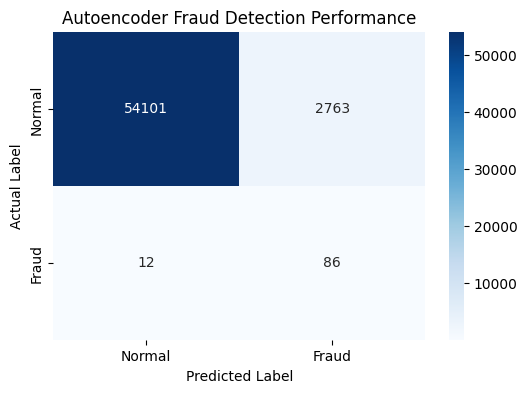

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predict (reconstruct) on the test set
test_predictions = model.predict(X_test_scaled)

# Calculate the Mean Squared Error (Reconstruction Error)
mse = np.mean(np.power(X_test_scaled - test_predictions, 2), axis=1)

# Set a threshold for anomaly detection (e.g., top 1% or a fixed value)
threshold = np.percentile(mse, 95)
print(f"Using an anomaly threshold of: {threshold:.4f}")

# Convert to binary predictions based on threshold
y_pred = (mse > threshold).astype(int)

# Evaluate the results
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Autoencoder Fraud Detection Performance')
plt.show()

### Tuning the Decision Threshold

Because we are using reconstruction error to detect anomalies, finding the exact right threshold is critical. The threshold we chose earlier (the 95th percentile) was just a starting point.

Let's plot a **Precision-Recall Curve** using the actual reconstruction errors to see the trade-off, and evaluate the model using a stricter threshold.

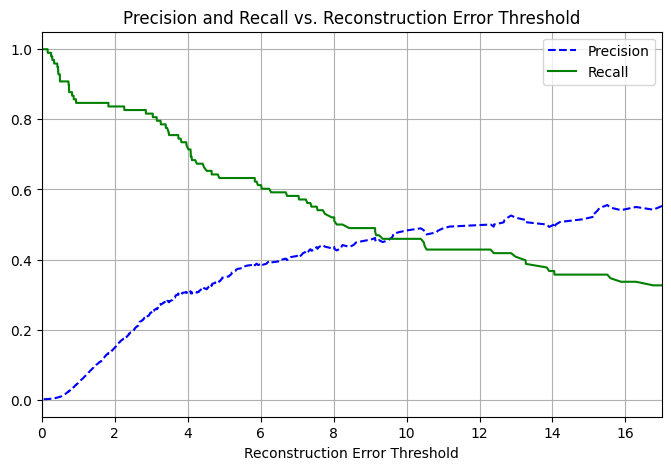


--- Results with Stricter Threshold = 1.9533 ---

Confusion Matrix:
[[56376   488]
 [   16    82]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     56864
       Fraud       0.14      0.84      0.25        98

    accuracy                           0.99     56962
   macro avg       0.57      0.91      0.62     56962
weighted avg       1.00      0.99      0.99     56962



In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Calculate precision and recall for various thresholds using MSE as our "anomaly score"
precisions, recalls, thresholds = precision_recall_curve(y_test, mse)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
plt.xlabel('Reconstruction Error Threshold')
plt.title('Precision and Recall vs. Reconstruction Error Threshold')
plt.legend()
plt.grid(True)
# Limit the x-axis to the 99.9th percentile to zoom in on the relevant area
plt.xlim([0, np.percentile(mse, 99.9)])
plt.show()

# Let's try a stricter threshold to reduce false positives (e.g., top 1% instead of 5%)
custom_threshold = np.percentile(mse, 99)
y_pred_custom = (mse > custom_threshold).astype(int)

print(f"\n--- Results with Stricter Threshold = {custom_threshold:.4f} ---")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_custom))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_custom, target_names=['Normal', 'Fraud']))

### Evaluating the Results: Autoencoder vs. Isolation Forest

In the previous module you used an **Isolation Forest** on this same credit card dataset. It is tempting to line the two sets of numbers up side by side and declare a winner. Before you do, look carefully at how each model was given its decision boundary.

#### The Golden Rule of Autoencoders for Anomaly Detection

As we saw in the training step, **we must train the Autoencoder exclusively on "Normal" data.** If we had trained it on a dataset containing fraud, it would have learned the complex patterns of fraud as well, resulting in low reconstruction errors for malicious transactions. By restricting its worldview to only legitimate behavior, fraudulent transactions cause the neural network to fail in its reconstruction, creating the high error spike we use to detect them.

#### What each model can represent

* **Isolation Forest** isolates anomalies by randomly partitioning the feature space. It is fast, scale-invariant, and needs no training labels — but it carves the space with axis-aligned cuts, so it struggles when "normal" has a complex, curved shape.
* **The Autoencoder** learns a compressed non-linear representation of normal behavior. If a fraudulent transaction subtly mimics a normal one, the bottleneck still fails to reconstruct the malicious deviations, producing a high error. This expressiveness is the deep learning advantage — when you have enough clean normal data to learn from.

#### Now look at how we chose the threshold

Read back through the two notebooks and compare these three things:

1. **Where the cutoff came from.** The Isolation Forest was given `contamination` up front. How did we pick the Autoencoder's threshold — and what data were we looking at when we picked it?
2. **What each model saw during training.** The Autoencoder was trained on normal transactions only. Was the Isolation Forest given the same courtesy?
3. **Which metric is being quoted.** At the 95th-percentile threshold the Autoencoder reached 0.88 recall on fraud — with 0.03 precision, meaning roughly 97% of its alarms were false. Would a SOC accept that trade?

> **Question:** Was the comparison between the Isolation Forest and the Autoencoder fair? If you think it was not, describe specifically what you would change to make it fair — then say which model you would actually deploy, and why.
>
> **[insert response]**

This matters beyond this one comparison. Published results in security ML are frequently reported exactly this way: a new model is tuned carefully against the test set while the baseline is run at its defaults. The numbers are not fabricated, but the comparison is not measuring what it claims to. Learning to spot this is more valuable than learning any single architecture.

## Core Concepts and Libraries

Now that you've seen Deep Learning in action, let's take a step back and understand the engine driving these results. Deep Learning is a powerful tool, but it requires an understanding of its building blocks and the ecosystem of tools used to build them.

### The Building Blocks of Neural Networks

*   **Neurons (Nodes):** The fundamental unit of a neural network. It receives input, applies a mathematical weight and bias, and passes the result through an activation function.
*   **Layers:**
    *   **Input Layer:** Receives the raw data (e.g., scaled transaction features).
    *   **Hidden Layers:** Where the "deep" in deep learning comes from. These layers perform complex feature extraction and pattern recognition.
    *   **Output Layer:** Produces the final prediction (e.g., a probability between 0 and 1 indicating fraud).
*   **Activation Functions:** Functions like **ReLU** (Rectified Linear Unit) and **Sigmoid** introduce non-linearity, allowing the network to learn complex boundaries rather than just simple straight lines.
*   **Overfitting and Dropout:** Deep networks can easily memorize the training data. **Dropout** layers randomly turn off a percentage of neurons during training, forcing the network to learn robust, generalized patterns rather than relying on specific paths.

### Essential Libraries for Cyber AI

To build these models, we rely on a stack of industry-standard Python libraries:

1.  **TensorFlow & Keras:** Developed by Google, TensorFlow is the core framework for building and training machine learning models. **Keras** is the high-level API running on top of TensorFlow that makes building neural networks intuitive and readable (like stacking Lego bricks).
2.  **Scikit-Learn (sklearn):** While not a deep learning library itself, it is essential for the data preparation pipeline—splitting data, scaling features (StandardScaler), and evaluating performance (classification reports, precision-recall curves).
3.  **Pandas & NumPy:** The workhorses of data manipulation and numerical computing. We use them to load, clean, and shape our security logs or transaction datasets before feeding them to the network.



## Section 1: Data Preparation and Foundations

Before we can build complex deep learning models, we need to understand how these models expect to receive data. Neural networks don't understand text or tables; they only understand numbers, and specifically, they work best when those numbers are structured as **Tensors** and scaled appropriately.

### 1.1 Tensors: The Language of Deep Learning
A tensor is essentially a multi-dimensional array.
* A 0D tensor is a scalar (a single number).
* A 1D tensor is a vector (a list of numbers).
* A 2D tensor is a matrix (like a table or grayscale image).
* A 3D tensor is an array of matrices (like a color image with RGB channels).

In [ ]:
import tensorflow as tf

# Let's create some basic tensors
# A 1D Tensor (Vector) - e.g., features of a single network packet
packet_features = tf.constant([1500.0, 80.0, 1.0])
print("1D Tensor (Vector):\n", packet_features)
print("Shape:", packet_features.shape)

# A 2D Tensor (Matrix) - e.g., a batch of 3 packets, each with 3 features
batch_features = tf.constant([
    [1500.0, 80.0, 1.0],
    [64.0, 443.0, 0.0],
    [1024.0, 22.0, 1.0]
])
print("\n2D Tensor (Matrix):\n", batch_features)
print("Shape:", batch_features.shape)

1D Tensor (Vector):
 tf.Tensor([1.5e+03 8.0e+01 1.0e+00], shape=(3,), dtype=float32)
Shape: (3,)

2D Tensor (Matrix):
 tf.Tensor(
[[1.500e+03 8.000e+01 1.000e+00]
 [6.400e+01 4.430e+02 0.000e+00]
 [1.024e+03 2.200e+01 1.000e+00]], shape=(3, 3), dtype=float32)
Shape: (3, 3)


### 1.2 Data Scaling (Normalization & Standardization)
Neural networks compute gradients to update their weights. If you have one feature ranging from 0 to 1 (like a boolean flag) and another ranging from 0 to 65,535 (like a network port), the larger feature will dominate the learning process, making training unstable or extremely slow.

Always scale your numerical features!

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Example data: [Packet Size (bytes), Port Number]
raw_data = np.array([
    [1500, 80],
    [64, 443],
    [1024, 22],
    [40, 53]
], dtype=float)

print("Raw Data:\n", raw_data)

# Min-Max Scaling (Scales between 0 and 1)
min_max_scaler = MinMaxScaler()
scaled_min_max = min_max_scaler.fit_transform(raw_data)
print("\nMin-Max Scaled Data:\n", scaled_min_max)

# Standard Scaling (Scales to mean=0, variance=1)
standard_scaler = StandardScaler()
scaled_standard = standard_scaler.fit_transform(raw_data)
print("\nStandard Scaled Data:\n", scaled_standard)

Raw Data:
 [[1500.   80.]
 [  64.  443.]
 [1024.   22.]
 [  40.   53.]]

Min-Max Scaled Data:
 [[1.         0.13776722]
 [0.01643836 1.        ]
 [0.6739726  0.        ]
 [0.         0.0736342 ]]

Standard Scaled Data:
 [[ 1.34229713 -0.40716968]
 [-0.94422562  1.71948634]
 [ 0.58436897 -0.74696596]
 [-0.98244048 -0.56535071]]


### 1.3 Encoding Categorical Data
Cybersecurity datasets are full of categorical data: Protocol types (TCP, UDP, ICMP), HTTP methods (GET, POST), or Alert Severity (Low, Medium, High). Neural networks need these converted to numbers.

For variables without an inherent order, we use **One-Hot Encoding**.

In [ ]:
import pandas as pd

# A simple dataset of network connections
data = {
    'Source_IP': ['192.168.1.5', '10.0.0.2', '172.16.0.4'],
    'Protocol': ['TCP', 'UDP', 'ICMP'],
    'Action': ['Allow', 'Deny', 'Allow']
}
df_network = pd.DataFrame(data)
print("Original Categorical Data:")
display(df_network)

# Apply One-Hot Encoding to the 'Protocol' column
# This creates a new binary column for each unique protocol
df_encoded = pd.get_dummies(df_network, columns=['Protocol'])
print("\nOne-Hot Encoded Data:")
display(df_encoded)

Original Categorical Data:


,Source_IP,Protocol,Action
0,192.168.1.5,TCP,Allow
1,10.0.0.2,UDP,Deny
2,172.16.0.4,ICMP,Allow



One-Hot Encoded Data:


,Source_IP,Action,Protocol_ICMP,Protocol_TCP,Protocol_UDP
0,192.168.1.5,Allow,False,True,False
1,10.0.0.2,Deny,False,False,True
2,172.16.0.4,Allow,True,False,False


### Section 1 Exercise: Data Prep Mini-Challenge

Now it's your turn! Complete the following tasks to prepare a mini security dataset for a neural network:

1. **Tensors:** Create a 2D TensorFlow tensor representing 4 network packets, each with 2 features (e.g., packet size and TTL).
2. **Scaling:** A dataset of login attempts has wildly different ranges (number of failed logins vs. session duration). Use `StandardScaler` to scale this data.
3. **Encoding:** You have a dataset of security alerts. Use pandas to One-Hot Encode the `Alert_Type` column.

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# --- TASK 1: Tensors ---
# TODO: Create a 2D tensor with 4 rows and 2 columns containing any float numbers.
my_tensor = tf.constant([
    # Add your rows here
])
print("Task 1 Tensor:\n", my_tensor)

# --- TASK 2: Scaling ---
login_data = np.array([
    [5.0, 120.0],  # 5 failed logins, 120s duration
    [1.0, 300.0],
    [15.0, 15.0],
    [0.0, 600.0]
])
# TODO: Initialize a StandardScaler and scale the 'login_data'
# scaled_logins =
# print("\nTask 2 Scaled Data:\n", scaled_logins)

# --- TASK 3: Encoding ---
alert_df = pd.DataFrame({
    'IP': ['10.1.1.1', '10.1.1.2', '10.1.1.3'],
    'Alert_Type': ['Phishing', 'Malware', 'Phishing']
})
# TODO: Use pd.get_dummies to one-hot encode the 'Alert_Type' column
# encoded_alerts =
# print("\nTask 3 Encoded Alerts:\n")
# display(encoded_alerts)

Task 1 Tensor:
 tf.Tensor([], shape=(0,), dtype=float32)


## Section 2: Supervised Learning with MLPs (Hyperparameter Tuning)

Earlier, we used an **Autoencoder** (Unsupervised Learning) to detect fraud by finding anomalies. Now, let's explore **Supervised Learning** using a **Multi-Layer Perceptron (MLP)**. If we have a dataset where the fraud is clearly labeled, an MLP can learn the direct mapping between the transaction features and the fraud label.

However, neural networks are not "one-size-fits-all." To get the best performance out of an MLP, we must tune its **hyperparameters**—the structural settings that govern how the network learns.

### The Anatomy of our MLP
Let's break down the key components you can tune:

1.  **Number of Hidden Layers (Depth):**
    *   Adding more layers allows the network to learn increasingly complex, abstract features.
    *   *Trade-off:* Too many layers can lead to **overfitting** (memorizing the training data but failing on new data) and makes training computationally expensive.
2.  **Number of Neurons per Layer (Width):**
    *   More neurons give the layer more "capacity" to memorize patterns.
    *   *Trade-off:* Similar to depth, too many neurons can lead to overfitting. A common practice is to use powers of 2 (16, 32, 64, 128) and gradually decrease the number of neurons as you get closer to the output layer (creating a funnel shape).
3.  **Dropout Rate:**
    *   Dropout is a regularization technique. During training, a Dropout layer randomly "turns off" a percentage of neurons in the previous layer (e.g., `0.2` means 20% are dropped).
    *   This forces the network to not rely entirely on a few specific neurons, resulting in a more generalized model.
4.  **Activation Functions:**
    *   **ReLU (Rectified Linear Unit):** The standard for hidden layers. It is computationally efficient and helps the network learn non-linear patterns.
    *   **Sigmoid:** Used in the final output layer for binary classification, as it squashes the final prediction into a probability between 0 and 1.

### The Trade-off: Underfitting vs. Overfitting
*   **Underfitting:** The model is too simple (e.g., only 1 hidden layer with 4 neurons). It fails to learn the underlying patterns. Both training and validation accuracy will be low.
*   **Overfitting:** The model is too complex (e.g., 5 layers with 512 neurons each, and no dropout). It memorizes the exact training data, including the noise. Training accuracy will be near 100%, but validation accuracy will stall or decrease.

### Section 2 Exercise: Tune the MLP

Your task is to build a new MLP for our Credit Card Fraud dataset.

**Instructions:**
1. Modify the `Sequential` model below.
2. Add at least one more `Dense` hidden layer.
3. Change the number of neurons (try 64 or 128 for the first layer).
4. Adjust the `Dropout` rates to see if it helps stabilize the validation loss.
5. Run the cell to train your custom model and see if you can beat the baseline AUC score!

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
import tensorflow as tf
import numpy as np
from sklearn.metrics import f1_score

# --- TASK: Tune the Hyperparameters ---
# Modify the architecture below.
tuned_model = Sequential([
    # Added explicit Input layer for proper summary display
    Input(shape=(X_train_scaled.shape[1],)),

    # 1st Hidden Layer
    Dense(64, activation='relu'),
    Dropout(0.3), # 30% dropout

    # 2nd Hidden Layer
    Dense(32, activation='relu'),
    Dropout(0.2),

    # 3rd Hidden Layer (Added for better representation)
    Dense(16, activation='relu'),
    Dropout(0.2),

    # Output Layer (Keep this exactly as is for binary classification!)
    Dense(1, activation='sigmoid')
])

# Compile the tuned model
tuned_model.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

print("Your Tuned Model Architecture:")
tuned_model.summary()

# Calculate class weights for the highly imbalanced dataset
neg, pos = np.bincount(y_train)
total = neg + pos
weight_for_0 = (1 / neg) * (total / 2.0)
weight_for_1 = (1 / pos) * (total / 2.0)
class_weight = {0: weight_for_0, 1: weight_for_1}

# Train the tuned model
print("\nTraining the tuned model...")
history_tuned = tuned_model.fit(
    X_train_scaled,
    y_train,
    epochs=10,
    batch_size=2048,
    validation_split=0.2,
    class_weight=class_weight,
    verbose=1
)
print("Training complete!")

# --- NEW: Evaluate the model ---
print("\n--- Final Test Set Evaluation ---")
results = tuned_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]*100:.2f}%")
print(f"Test AUC: {results[2]:.4f}")

# Calculate F1-score
y_pred_probs = tuned_model.predict(X_test_scaled, verbose=0)
y_pred_classes = (y_pred_probs > 0.5).astype(int)
f1 = f1_score(y_test, y_pred_classes)
print(f"F1-score: {f1:.4f}")

Your Tuned Model Architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)


Training the tuned model...
Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.6706 - auc: 0.8834 - loss: 0.4402 - val_accuracy: 0.9908 - val_auc: 0.9703 - val_loss: 0.2437
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9590 - auc: 0.9569 - loss: 0.2612 - val_accuracy: 0.9876 - val_auc: 0.9811 - val_loss: 0.1280
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9678 - auc: 0.9676 - loss: 0.2126 - val_accuracy: 0.9808 - val_auc: 0.9850 - val_loss: 0.1206
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9580 - auc: 0.9734 - loss: 0.1947 - val_accuracy: 0.9784 - val_auc: 0.9856 - val_loss: 0.1080
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9645 - auc: 0.9739 - loss: 0.1812 - val_accuracy: 0.9749 - val_auc: 0.9855 - val_loss: 0.1124
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9640 - auc: 0.9800 - loss: 0.1593 - val_accuracy: 0.9843 - val_auc: 0.9825 - val_loss: 0.0772
Epoch 7/10
90/90 ━━━━━

### Fixing the F1-Score: Tuning the Decision Threshold

You might have noticed that despite a high Accuracy and AUC, the **F1-score is surprisingly low**. Why did this happen?

This is a classic trap when using `class_weight`. By telling the neural network that missing a fraudulent transaction is hundreds of times worse than a false alarm, the model becomes "paranoid." It starts outputting higher probabilities for *any* transaction that looks slightly suspicious.

When we use the default threshold of `0.5` (i.e., `y_pred_probs > 0.5`), thousands of normal transactions cross that line. This destroys our **Precision** (most of our "fraud" alarms are false positives), which in turn drags the F1-score down to the floor.

To fix this, we shouldn't blindly use 0.5. Just like we did with the Autoencoder, we need to analyze the predicted probabilities and find the **optimal threshold** that balances Precision and Recall to maximize the F1-score.

In [ ]:
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report
import numpy as np

# Get the exact predicted probabilities from the MLP
y_pred_probs = tuned_model.predict(X_test_scaled, verbose=0)

# Calculate precision, recall, and thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_probs)

# Calculate F1 scores for each threshold
# (We add 1e-10 to the denominator to prevent division by zero)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# Find the exact threshold that gives us the highest F1 score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Optimal Decision Threshold: {best_threshold:.4f}")
print(f"Maximized F1-Score: {best_f1:.4f}")

# Convert probabilities to binary predictions using our new, smarter threshold
y_pred_optimal = (y_pred_probs >= best_threshold).astype(int)

# Evaluate the results
print("\n--- Results with Optimal Threshold ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_optimal))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimal, target_names=['Normal', 'Fraud']))

Optimal Decision Threshold: 0.9985
Maximized F1-Score: 0.8223

--- Results with Optimal Threshold ---
Confusion Matrix:
[[56846    18]
 [   17    81]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.82      0.83      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



### Section 2 Takeaway

*   **Customization is Key:** A neural network's architecture (its layers and neurons) dictates its learning capacity. Tuning these hyperparameters is essential for maximizing performance on a specific dataset.
*   **The Overfitting Trap:** Simply making a network deeper or wider doesn't automatically make it better. It often leads to **overfitting**, where the model memorizes the training data but fails to generalize to unseen data.
*   **Regularization saves the day:** Techniques like **Dropout** act as a countermeasure to overfitting. By forcing the network to randomly drop connections during training, it learns more robust and generalized patterns.
*   **Threshold Tuning is Critical:** When handling highly imbalanced data (like fraud detection) using `class_weight`, the default decision threshold (0.5) is rarely optimal. It's crucial to analyze Precision-Recall curves and tune the threshold to balance false positives and false negatives, maximizing metrics like the F1-score.
*   **Iterative Process:** Finding the perfect architecture and threshold is rarely done on the first try; it is an iterative process of observing metrics and adjusting accordingly.

## Section 3: Sequence Modeling for DGA Detection (CNNs vs LSTMs)

Many types of malware use **Domain Generation Algorithms (DGAs)** to establish communication with their Command and Control (C2) servers. Instead of hardcoding a single IP address, the malware generates hundreds of random-looking domains daily (e.g., `xdfqeirutbv.com`).

To detect this, we need to analyze the *sequence of characters* in the domain name. We will compare two powerful Deep Learning architectures for this task: **1D Convolutional Neural Networks (CNNs)** and **Long Short-Term Memory (LSTM)** networks.

While CNNs are famous for 2D image processing, a **1D CNN** can scan across text sequences. It acts like an "n-gram" detector, sliding a filter across the characters to find local patterns (like weird consonant clusters).

### 3.1 Loading the Domain Dataset
First, we load our dataset containing both legitimate domains and DGA-generated domains.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The URLs to the CSV files
url_dga = DATA_URL + "dga_websites.csv"
url_legit = DATA_URL + "legit_websites.csv"

print(f"Downloading and loading DGA data...")
df_dga = pd.read_csv(url_dga)
print(f"Downloading and loading Legit data...")
df_legit = pd.read_csv(url_legit)

print("Datasets loaded successfully!")
print(f"DGA Dataset shape: {df_dga.shape} (rows, columns)")
print(f"Legit Dataset shape: {df_legit.shape} (rows, columns)")

Datasets loaded successfully!
DGA Dataset shape: (337500, 2) (rows, columns)
Legit Dataset shape: (337398, 2) (rows, columns)


### 3.2 Preprocessing Text for Neural Networks
Neural networks only understand numbers. We must convert our strings of characters into numerical tokens, and pad them so they all have the same length. We will also balance the dataset.

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------------
# Combine the two sources.
#
# We deliberately do NOT oversample here. The two files are already
# balanced (337,500 DGA vs 337,398 legitimate -- a 0.03% difference),
# so oversampling buys us nothing. Worse, sampling with replacement
# BEFORE the train/test split would duplicate rows across both sides.
# The cell below this one shows exactly how much damage that does.
# ------------------------------------------------------------------
df = pd.concat([df_dga, df_legit], ignore_index=True)
df['domain'] = df['domain'].astype(str)
df['label'] = (df['class'] == 'dga').astype(int)

# Remove duplicate domains BEFORE splitting, so that no single domain
# can ever land in both the training set and the test set.
before = len(df)
df = df.drop_duplicates(subset='domain').reset_index(drop=True)
print(f"Dropped {before - len(df):,} duplicate domains ({len(df):,} remain)")

# Split FIRST. Any balancing or resampling happens on the training set only.
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df['label']
)

# Tokenize at the character level -- fit on the TRAINING split only.
# Fitting the tokenizer on all the data would let the test set influence
# the vocabulary, which is a subtle form of leakage in its own right.
tokenizer = Tokenizer(char_level=True, lower=True)
tokenizer.fit_on_texts(train_df['domain'])

max_domain_length = 50
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(train_df['domain']),
                            maxlen=max_domain_length, padding='post')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(test_df['domain']),
                           maxlen=max_domain_length, padding='post')
y_train_seq = train_df['label'].values
y_test_seq = test_df['label'].values

vocab_size = len(tokenizer.word_index) + 1
print(f"Vocabulary size: {vocab_size}")
print(f"Training samples: {X_train_seq.shape[0]:,}")
print(f"Test samples:     {X_test_seq.shape[0]:,}")
print(f"Fraction DGA in training set: {y_train_seq.mean():.3f}")

# Verify the fix: no domain should appear on both sides.
overlap = len(set(train_df['domain']) & set(test_df['domain']))
print(f"Domains appearing in BOTH train and test: {overlap}")


> ### Why the split had to come first
>
> An earlier version of this notebook balanced the classes *before* splitting, using `df.sample(n=..., replace=True)`. It looked harmless. It was not.
>
> Sampling with replacement draws the same row more than once. Feeding 675,000 rows built that way into `train_test_split` scatters those copies across both sides. The model is then tested on domains it memorized during training, and reports a score that says nothing about how it will handle a domain it has never seen.
>
> Run the cell below to measure the damage yourself. This is the **memorize vs. generalize** distinction from Module 2, hiding inside a preprocessing step that looks like good practice.

In [ ]:
# ------------------------------------------------------------------
# Demonstration: how much leakage did the old oversampling introduce?
# This cell trains nothing. It only measures the data pipeline.
# ------------------------------------------------------------------

# Reproduce the OLD (broken) approach
n = max(len(df_dga), len(df_legit))
bad = pd.concat([
    df_dga.sample(n=n, replace=True, random_state=SEED),
    df_legit.sample(n=n, replace=True, random_state=SEED)
], ignore_index=True)
bad['label'] = (bad['class'] == 'dga').astype(int)

bad_train, bad_test = train_test_split(
    bad, test_size=0.2, random_state=SEED, stratify=bad['label']
)

leaked = bad_test['domain'].isin(pd.Index(bad_train['domain'].unique())).sum()

print("OLD PIPELINE (oversample, then split)")
print(f"  rows after oversampling : {len(bad):,}")
print(f"  unique domains          : {bad['domain'].nunique():,}")
print(f"  duplicate rows created  : {len(bad) - bad['domain'].nunique():,}")
print(f"  test rows the model already saw in training: "
      f"{leaked:,} / {len(bad_test):,}  ({leaked / len(bad_test) * 100:.1f}%)")

print()
print("NEW PIPELINE (deduplicate, then split)")
print(f"  test rows the model already saw in training: 0 / {len(test_df):,}  (0.0%)")

print()
print("Any accuracy or F1 reported under the old pipeline was measuring")
print("memorization on more than half the test set.")


> ### An uncomfortable follow-up
>
> You have just measured that the old pipeline let the model memorize more than half its own test set. So how much did the reported score actually shrink once we fixed it?
>
> | | leaky pipeline | corrected pipeline |
> |---|---|---|
> | 1D CNN, 3 epochs | 0.8885 F1 | **0.8820 F1** |
> | LSTM, 3 epochs | 0.8423 F1 | **0.8378 F1** |
>
> Almost nothing. Under half a point.
>
> That is not a sign the leak was harmless, and it is worth being precise about why. These models are **underfit** relative to the data: a small character-level network trained for three epochs on 675,000 domains has nowhere near the capacity to memorize individual examples, so duplicates in the test set gave it little to exploit. Train for thirty epochs instead of three, or widen the network, and the gap opens up — memorization requires capacity, and we gave it very little.
>
> The real cost of the leak was never the size of the number. It was that **you had no way to know the size of the number.** Before the fix, 0.8885 might have been an honest score or might have been mostly memorization, and nothing in the output distinguished those two worlds. After the fix, 0.8820 means what it says.
>
> Keep this in mind for the rest of the module. You will meet two more defects — one in Section 4, one in Section 5 — and their consequences are wildly different in size. One costs an entire class; the other costs almost nothing. **The magnitude of a data defect cannot be reasoned out in advance. It has to be measured.** What you can reason about is whether your number is *checkable*, and that is the property worth defending.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from sklearn.metrics import f1_score

# Build the 1D CNN
cnn_model = Sequential([
    Input(shape=(max_domain_length,)), # Added explicit Input layer
    Embedding(input_dim=vocab_size, output_dim=32),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.build((None, max_domain_length))
cnn_model.summary()

print("\nTraining the 1D CNN...")
history_cnn = cnn_model.fit(X_train_seq, y_train_seq, epochs=3, batch_size=1024, validation_split=0.2, verbose=1)

print("\nEvaluating CNN on Test Set:")
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_seq, y_test_seq, verbose=0)
print(f"CNN Test Accuracy: {cnn_acc * 100:.2f}%")

cnn_test_preds = (cnn_model.predict(X_test_seq, verbose=0) > 0.5).astype(int)
cnn_f1 = f1_score(y_test_seq, cnn_test_preds)
print(f"CNN Test F1-Score: {cnn_f1:.4f}")

A 1D CNN is very fast to train and often achieves strong accuracy on text classification tasks by picking up on local character combinations. Next, let's see how an LSTM handles the same task.

### 3.3 Sequence Modeling with LSTMs

While CNNs look for local patterns, **Recurrent Neural Networks (RNNs)**, specifically **Long Short-Term Memory (LSTM)** networks, are designed to read data sequentially. They keep a "memory" of past characters to understand the context of the entire sequence.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense
from sklearn.metrics import f1_score

# Build the LSTM
lstm_model = Sequential([
    Input(shape=(max_domain_length,)), # Added explicit Input layer
    Embedding(input_dim=vocab_size, output_dim=32),
    LSTM(64),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.build((None, max_domain_length))
lstm_model.summary()

print("\nTraining the LSTM...")
history_lstm = lstm_model.fit(X_train_seq, y_train_seq, epochs=3, batch_size=1024, validation_split=0.2, verbose=1)

print("\nEvaluating LSTM on Test Set:")
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_seq, y_test_seq, verbose=0)
print(f"LSTM Test Accuracy: {lstm_acc * 100:.2f}%")

lstm_test_preds = (lstm_model.predict(X_test_seq, verbose=0) > 0.5).astype(int)
lstm_f1 = f1_score(y_test_seq, lstm_test_preds)
print(f"LSTM Test F1-Score: {lstm_f1:.4f}")

### 3.4 Testing and Comparing Models
Let's see how both models perform on some custom domains.

In [ ]:
test_domains = [
    # Legitimate Domains
    'google.com', 'wikipedia.org', 'apple.com', 'amazon.com',
    'microsoft.com', 'github.com', 'netflix.com', 'linkedin.com',
    'stackoverflow.com', 'nytimes.com', 'bbc.co.uk', 'whitehouse.gov', 'mit.edu',

    # DGA / Random Domains
    'xdfqeirutbv.com', 'a1b2c3d4e5f6.info', 'qwerasdfzxcv.com', 'zxcvbnmqwer.net',
    'asdfghjklqwerty.org', 'poiuytrewqasdf.biz', 'mnbvcxzlkjhgf.info',
    'aabbccddeeffgg.com', '1a2b3c4d5e6f.net', 'zxywvutsrqpon.org',
    'alksdjfhg.com', 'vbnmghjkl.net', '1234567890qwerty.biz'
]

test_sequences = tokenizer.texts_to_sequences(test_domains)
X_custom_test = pad_sequences(test_sequences, maxlen=max_domain_length, padding='post')

cnn_preds = cnn_model.predict(X_custom_test)
lstm_preds = lstm_model.predict(X_custom_test)

print(f"\n{'Domain':25} | {'CNN Pred':10} | {'LSTM Pred':10}")
print("-" * 51)
for dom, c_pred, l_pred in zip(test_domains, cnn_preds, lstm_preds):
    c_class = "DGA" if c_pred[0] > 0.5 else "Legit"
    l_class = "DGA" if l_pred[0] > 0.5 else "Legit"
    print(f"{dom:25} | {c_class:10} | {l_class:10}")

### Section 3 Takeaway: Deep Learning for Sequence Analysis in Security

When analyzing sequential data like domain names, network packet payloads, or system API calls, traditional machine learning often falls short. Deep learning gives us two distinct engines for the job, and this section was really a head-to-head between them.

#### 1. 1D CNNs: the fast pattern matchers

Think of a 1D CNN as an ultra-fast sliding scanner.

* **Mechanism:** it slides a kernel across the sequence, extracting local patterns — n-grams of characters, like the improbable consonant clusters "qwe" or "zxc" that give away a generated domain — and `GlobalMaxPooling1D` keeps the strongest match wherever it occurred.
* **Strength:** speed. Convolutions across the whole sequence are computed in parallel, which suits real-time traffic analysis and high-throughput log scanning.
* **Limitation:** no memory of overall sequence structure. It sees a bag of strong local matches, not an ordered reading.

#### 2. LSTMs: the context-aware analyzers

Think of an LSTM as a meticulous reader.

* **Mechanism:** it processes the sequence step by step, updating an internal memory state, learning context and long-range dependencies.
* **Strength:** problems where *order over distance* carries the meaning — malicious PowerShell, phishing prose, a sequence of user actions that is only anomalous in combination.
* **Limitation:** it cannot parallelize across time. Step B waits for step A.

#### What we actually measured

On the deduplicated split, three epochs each:

| model | test accuracy | test F1 | training time | inference on 135k domains |
|---|---|---|---|---|
| 1D CNN | 88.95% | **0.8820** | 51s | 8.5s |
| LSTM | 85.20% | **0.8378** | 264s | 23.2s |

The CNN was more accurate **and** roughly five times faster to train and nearly three times faster at inference. For this task it wins outright, with no trade-off to argue about.

That result deserves a moment's thought, because the LSTM is the more sophisticated architecture and it lost. Its advantage is long-range dependency, and a DGA domain is around 15 characters with no meaningful long-range structure — the giveaway is local character statistics, which is exactly what a convolution is built to find. The LSTM paid for machinery this problem does not need.

**The general lesson:** match the architecture to the structure of the signal, not to its reputation. In a SOC processing millions of DNS queries a minute, the 1D CNN is the deployable choice here — better F1, a fraction of the compute.

#### And one note on the metric

Throughout this section we quoted **F1** rather than accuracy. On a balanced dataset like this one those track each other closely, so it makes little difference. It will make an enormous difference in Section 4 and again in the final lab, where the classes are anything but balanced. Building the habit now is cheap.

### Section 3 Exercise: Sequence Model Tuning Challenge

Your turn. Build and tune a sequence model — CNN layers, LSTM layers, or a mix — and get an **F1 score above 0.90** on the test set.

That target is deliberately tight. The baseline CNN reached 0.8820 and the baseline LSTM 0.8378, so you need a real improvement over both, not a lucky seed. It is achievable: our reference solution reaches roughly 0.909, which clears the bar with very little room to spare.

**Rules:**

1. You may change the number of filters, units, dense layers, kernel size, embedding dimension, or dropout rates.
2. You may **not** train for more than 4 epochs. Efficiency is part of the problem — a model that needs an hour to catch a DGA is not a DGA detector.

**Diagnostic guide:**

* **Overfitting:** training accuracy climbing well above validation accuracy, and validation F1 stalling or falling. *Fix: raise dropout, or reduce units and filters.*
* **Underfitting:** training and validation accuracy both stuck low and moving together. *Fix: add filters, units, or another layer.*

**Hint:** the baseline CNN uses 64 filters with a kernel size of 3. Widening the filters and the window gives each one more context to work with, and an extra dense layer before the output gives the network somewhere to combine what it found. Watch the validation gap as you scale up.

**A word of warning, now that you have seen how this notebook works.** If your F1 lands at 0.99, do not celebrate — go and find out what you broke. On this data, at four epochs, that number is not reachable honestly.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, LSTM
from sklearn.metrics import f1_score

# --- TASK: Build a better Sequence Model ---
# Design your architecture below.
my_model = Sequential([
    Input(shape=(max_domain_length,)), # Added Input layer so summary() works correctly
    Embedding(input_dim=vocab_size, output_dim=32),

    # --- YOUR CODE HERE ---
    # Add your Conv1D or LSTM layers, Dropouts, and hidden Dense layers here
    Conv1D(filters=128, kernel_size=4, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.4),
    # ---------------------

    # Keep this output layer the same
    Dense(1, activation='sigmoid')
])

# Compile the model
my_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
my_model.build((None, max_domain_length))
my_model.summary()

# Train for a MAXIMUM of 4 epochs
print("\nTraining custom model...")
history_custom = my_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=4, # Do not exceed 4 epochs!
    batch_size=1024,
    validation_split=0.2,
    verbose=1
)

# Evaluate the model
print("\nEvaluating Custom Model on Test Set...")
custom_preds = (my_model.predict(X_test_seq, verbose=0) > 0.5).astype(int)
custom_f1 = f1_score(y_test_seq, custom_preds)

print(f"\n--- Final Results ---")
print(f"Custom Model Test F1-Score: {custom_f1:.4f}")

if custom_f1 > 0.90:
    print("\n🎉 Challenge Passed! Excellent tuning!")
else:
    print("\nKeep trying! Tweak the layers, neurons, or dropout.")

---

## Section 4: Malware Classification with 2D CNNs

In Section 3 you used a **1D** CNN to slide a filter along a string of characters. Convolution was originally designed for something more familiar: **images**. Here we return to the two-dimensional form and apply it to a problem that at first sounds absurd.

### Turning a binary into a picture

A compiled Windows executable is just a sequence of bytes, and every byte is a number from 0 to 255. That happens to be exactly the range of a grayscale pixel.

So: read the bytes of a malware sample, lay them out row by row into a rectangle, and treat each byte as a pixel. You get an image. The idea comes from Nataraj et al. (2011), and the surprising result is that **malware from the same family produces visually similar images.**

That similarity is not a coincidence. It reflects real structure in the file:

* **Section layout.** Compiled binaries have a predictable internal organization — headers, code, imported function tables, embedded resources. Each region has its own texture. Dense code looks like fine static, padding looks like flat blocks, string tables look like repeating vertical bands.
* **Shared code.** Variants within a family are usually the same program recompiled or lightly modified, so most of the bytes — and therefore most of the image — are identical.
* **Packing signatures.** A packed or encrypted binary looks like uniform noise, and different packers produce visibly different noise.

### Why a defender would want this

* **No execution required.** Pure static analysis. Nothing is detonated, so there is no sandbox for the malware to detect or evade.
* **No signatures required.** A hash-based detector fails the instant one byte changes. A CNN reading overall texture tolerates small mutations, so it can flag a *variant* of a known family it has never seen.
* **Fast.** Convert to image, run a small CNN, done in milliseconds — which matters when triaging thousands of samples an hour.

### Set your expectations honestly

You will find papers reporting 96-99% accuracy on the dataset we are about to use. Those numbers are real, and they are also close to meaningless. Before this section ends you will understand exactly why — not from us telling you, but from measuring it.

Two things to keep in mind from the start:

1. The **Malimg** dataset was published in 2011. It is a benchmark, not a snapshot of today's threat landscape.
2. It contains only **malware**, sorted into families. There is no benign class. We are answering "which family is this?" and never "is this malicious at all?" — which is the question a real product has to answer first.

### 4.1 Loading the Malimg dataset

The original dataset is 1.2 GB of individual PNG files. We have pre-processed it into a single compressed NumPy archive: every sample resized to 64x64 grayscale, about 22 MB, which downloads in seconds and fits in memory.

| Array | Contents |
|---|---|
| `images` | 9,339 samples, each a 64x64 array of bytes (0-255) |
| `labels` | Integer 0-24 identifying the malware family |
| `families` | The 25 family names, indexed by label |
| `split` | The original `train` / `validation` assignment |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen
import io

print("Downloading Malimg (64x64 grayscale)...")
with urlopen(DATA_URL + "malimg_64.npz") as r:
    archive = np.load(io.BytesIO(r.read()), allow_pickle=False)

images     = archive["images"]     # (9339, 64, 64) uint8
labels     = archive["labels"]     # (9339,)        uint8, 0-24
families   = archive["families"]   # (25,)          family names
orig_split = archive["split"]      # (9339,)        'train' / 'validation'

print("Loaded successfully.")
print(f"Images: {images.shape}  dtype={images.dtype}  range={images.min()}-{images.max()}")
print(f"Families: {len(families)}")
print()
for i, fam in enumerate(families):
    print(f"  {i:2d}  {str(fam):<18} {(labels == i).sum():>5,} samples")


### 4.2 What does malware actually look like?

Before modeling anything, look at the data. The cell below shows four samples from each of six families.

Two things to notice. Within a row, the samples are different files — different hashes, different sizes on disk — yet they look nearly identical. Across rows, the families have visibly different textures. If *you* can tell these apart by eye, a CNN can learn to as well.

In [ ]:
show = [0, 2, 10, 15, 20, 24]
fig, axes = plt.subplots(len(show), 4, figsize=(7, 10))

for row, fam_idx in enumerate(show):
    idxs = np.where(labels == fam_idx)[0][:4]
    for col in range(4):
        ax = axes[row, col]
        ax.imshow(images[idxs[col]], cmap='gray', vmin=0, vmax=255)
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(str(families[fam_idx]), rotation=0, ha='right',
                          va='center', fontsize=9)

fig.suptitle("Malware binaries rendered as grayscale images", y=0.995)
plt.tight_layout()
plt.show()


### 4.3 Audit the data before you trust the benchmark

Section 3 taught you that a leaky split inflates your score. So before training anything, let's ask the obvious follow-up question about *this* dataset: **how many of these 9,339 samples are actually distinct?**

Many of these families are *polymorphic* — the malware rewrites small parts of itself on each infection specifically to defeat hash-based detection. Those variants differ by a handful of bytes. At 64x64 resolution such differences disappear, leaving samples that are byte-for-byte identical.

The cell below hashes every image and counts how many unique images each family actually contains. Run it before reading further, and look carefully at the top of the table.

In [ ]:
import hashlib
from collections import defaultdict, Counter

unique_hashes = defaultdict(set)
for img, lab in zip(images, labels):
    unique_hashes[int(lab)].add(hashlib.md5(img.tobytes()).hexdigest())

counts = Counter(labels.tolist())

rows = sorted(
    ((len(unique_hashes[i]) / counts[i], i, counts[i], len(unique_hashes[i]))
     for i in range(len(families)))
)

print(f"{'family':<20}{'samples':>9}{'unique':>9}{'unique %':>10}")
print("-" * 48)
for ratio, i, n, u in rows:
    print(f"{str(families[i]):<20}{n:>9,}{u:>9,}{ratio * 100:>9.0f}%")

total_unique = sum(len(v) for v in unique_hashes.values())
print("-" * 48)
print(f"{'TOTAL':<20}{len(images):>9,}{total_unique:>9,}{total_unique / len(images) * 100:>9.0f}%")

# How badly does the dataset's own split leak?
tr_hashes = {hashlib.md5(img.tobytes()).hexdigest()
             for img in images[orig_split == 'train']}
va_hashes = [hashlib.md5(img.tobytes()).hexdigest()
             for img in images[orig_split == 'validation']]
leaked = sum(1 for h in va_hashes if h in tr_hashes)
print()
print(f"Validation images that are byte-identical to a training image: "
      f"{leaked} / {len(va_hashes)}  ({leaked / len(va_hashes) * 100:.1f}%)")


### What that table just told you

Three findings, in increasing order of seriousness.

**1. The dataset's own split leaks.** About 15% of the validation images are byte-identical to a training image. Every accuracy measured against this split is partly a memorization score. You already know this pattern from Section 3 — but note that this time it arrived baked into a dataset distributed by researchers, not from a mistake in our own code.

**2. Two families are not really families at all.** `Yuner.A` ships 800 samples that reduce to **one** distinct image. `Autorun.K` ships 106 that reduce to **one**. Both are packed binaries whose variants are identical at this resolution.

**3. And those two single images are, to a CNN, the same image.** This is the one that matters. Compare the `Autorun.K` prototype against the `Yuner.A` prototype and the mean absolute difference is **0.097** on a 0-255 scale — 114 of 4,096 pixels differ at all, and only 5 differ by more than 10. For reference, the median distance between two family centroids in this dataset is 27.43. These two "different families" are roughly **280 times closer to each other** than a typical pair.

The consequence is not subtle. At 64x64 the 25-class problem is **unsolvable**: the model is shown the same picture with two different labels. It cannot do better than guessing between them, and because `Yuner.A` has ten times more training samples, it learns to always answer `Yuner.A`. You will confirm this yourself in the exercise, where `Yuner.A` scores perfect recall and `Autorun.K` scores exactly **zero**.

**An honest caveat about our preprocessing.** We resized every sample to 64x64. In the original Malimg format, image *width* is fixed by convention and *height* varies with file size — so the raw images carry a rough signal about how big the binary is, and our resize throws that away. It is possible these two families are separable at full resolution and we destroyed the evidence. We cannot check from here, and you should treat that as an open question rather than a settled one. It is a good illustration of a general rule: preprocessing is not a neutral step, and a resize is a modelling decision.

**How we will proceed.** We deduplicate, drop the two indistinguishable families, and split what remains ourselves. That leaves a **23-class** problem built from 7,978 distinct images.

> This is what it looks like to take a dataset seriously. The instinct to reach for the standard benchmark and the standard split is strong, because it makes your results comparable to everyone else's. Sometimes what it actually makes them is comparably wrong.

In [ ]:
from sklearn.model_selection import train_test_split

# --- Deduplicate: keep the first occurrence of each distinct image ---
seen, keep = set(), []
for i, img in enumerate(images):
    h = hashlib.md5(img.tobytes()).hexdigest()
    if h not in seen:
        seen.add(h)
        keep.append(i)
keep = np.array(keep)

X_unique = images[keep]
y_unique = labels[keep]
print(f"Deduplication: {len(images):,} samples -> {len(X_unique):,} distinct images")

# --- Drop families with too few distinct images to train or test on ---
MIN_UNIQUE = 5
usable = [i for i in range(len(families)) if (y_unique == i).sum() >= MIN_UNIQUE]
dropped = [str(families[i]) for i in range(len(families)) if i not in usable]
print(f"Dropping {len(dropped)} degenerate families: {', '.join(dropped)}")

mask = np.isin(y_unique, usable)
X_all = X_unique[mask]

# Remap the surviving labels to a contiguous range 0..22
remap = {old: new for new, old in enumerate(usable)}
y_all = np.array([remap[int(v)] for v in y_unique[mask]])
family_names = [str(families[i]) for i in usable]

print(f"Final task: {len(family_names)} classes, {len(X_all):,} images")

# --- Stratified split, so every family appears on both sides ---
X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)

# --- Scale to [0,1] and add the channel axis Conv2D expects ---
X_train_img = (X_train_img.astype("float32") / 255.0)[..., np.newaxis]
X_test_img  = (X_test_img.astype("float32")  / 255.0)[..., np.newaxis]

print()
print(f"Training set: {X_train_img.shape}")
print(f"Test set:     {X_test_img.shape}")
print(f"Smallest class in training set: {np.bincount(y_train_img).min()} images")
print(f"Largest class in training set:  {np.bincount(y_train_img).max()} images")
print(f"Imbalance ratio: {np.bincount(y_train_img).max() / np.bincount(y_train_img).min():.0f} to 1")


### 4.4 Building the CNN

This is a standard image classification stack. Three ideas are worth understanding rather than copying:

**`Conv2D` slides a small learned filter across the image.** The first layer's filters respond to simple local texture — an edge, a patch of noise, a repeating band. Because the same filter is applied at every position, the layer detects that texture *anywhere* in the file. That property is what lets the model tolerate code shifting slightly between variants.

**`MaxPooling2D` halves the spatial dimensions**, keeping the strongest response in each neighborhood. Stacking convolution and pooling means later layers see a larger effective region of the original image, so the network builds up from "fine static here" to "this file has the overall layout of a packed dropper."

**The output layer uses `softmax` over 23 neurons**, not a single `sigmoid`. Softmax forces the outputs to sum to 1, turning them into a probability distribution across families. We pair it with `sparse_categorical_crossentropy` — the multi-class counterpart of the binary cross-entropy you used earlier, which takes integer labels directly instead of requiring one-hot encoding.

Note also that we still carry a roughly 90-to-1 class imbalance. We keep it rather than resampling, because it is realistic — you will always have more samples of common families — and because it gives us something to measure in the next cell.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten,
                                     Dense, Dropout)

def build_malware_cnn(n_classes):
    """Defined as a function so the exercise can rebuild it without copy-paste."""
    m = Sequential([
        Input(shape=(64, 64, 1)),

        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),                 # 64 -> 32

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),                 # 32 -> 16

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),                 # 16 -> 8

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(n_classes, activation='softmax')
    ])
    m.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m

malware_cnn = build_malware_cnn(len(family_names))
malware_cnn.build((None, 64, 64, 1))
malware_cnn.summary()


In [ ]:
print("Training the malware CNN...")
history_malware = malware_cnn.fit(
    X_train_img, y_train_img,
    epochs=15,
    batch_size=64,
    validation_split=0.15,
    verbose=1
)
print("Training complete.")


### 4.5 Evaluating: accuracy is not the whole story

Compare the two headline numbers below.

**Overall accuracy** weights every sample equally, so the large families dominate it. **Macro F1** weights every *family* equally, so a family the model has quietly given up on drags it down hard.

On our reference run the model reached **97.99% accuracy** but only **0.949 macro F1**. That three-point gap is the imbalance showing through: the model is comfortably better at `Allaple.A`, with over 2,000 training samples, than at the families with a few dozen. Your numbers will land close to these but not identical — GPU non-determinism means even a fixed seed does not guarantee an exact match.

The gap matters operationally, because a family that is rare in your training data may be the active campaign on your network this week.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns

y_pred_img = malware_cnn.predict(X_test_img, verbose=0).argmax(axis=1)

acc         = (y_pred_img == y_test_img).mean()
macro_f1    = f1_score(y_test_img, y_pred_img, average='macro')
weighted_f1 = f1_score(y_test_img, y_pred_img, average='weighted')

print(f"Overall accuracy : {acc * 100:.2f}%")
print(f"Weighted F1      : {weighted_f1:.4f}   <- flattered by the large families")
print(f"Macro F1         : {macro_f1:.4f}   <- every family counts the same")
print()
print(classification_report(y_test_img, y_pred_img,
                            labels=np.arange(len(family_names)),
                            target_names=family_names,
                            zero_division=0))


In [ ]:
cm = confusion_matrix(y_test_img, y_pred_img, labels=np.arange(len(family_names)))

plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=family_names, yticklabels=family_names)
plt.xlabel('Predicted family')
plt.ylabel('Actual family')
plt.title('Malware Family Confusion Matrix')
plt.tight_layout()
plt.show()

errors = [(cm[i, j], family_names[i], family_names[j])
          for i in range(len(family_names))
          for j in range(len(family_names))
          if i != j and cm[i, j] > 0]
errors.sort(reverse=True)

print("Most frequent confusions:")
if errors:
    for count, actual, predicted in errors[:8]:
        print(f"  {count:3d}x  {actual}  ->  {predicted}")
else:
    print("  none")


### Section 4 Analysis: what did the model actually learn?

Look at your confusion matrix before reading on.

The mistakes are not spread randomly. On our reference run, essentially all of them fell between families that are genuinely *related*:

| confusion | count |
|---|---|
| `Swizzor.gen!E` predicted as `Swizzor.gen!I` | 17 |
| `C2LOP.gen!g` predicted as `C2LOP.P` | 3 |
| `C2LOP.P` predicted as `C2LOP.gen!g` | 3 |

Everything else was one or two samples. Those pairs really are close relatives sharing most of their code, so their byte-images genuinely look alike. Confusing two variants of one family is far less dangerous operationally than confusing a dropper with a keylogger — an analyst who receives "this is Swizzor" still gets the containment steps right.

Notice also what did *not* happen. `Allaple.A` and `Allaple.L` are the two largest families and share a name, so you might reasonably expect them to be confused. They were not. Related naming does not imply visual similarity, and visual similarity is what this model actually sees.

**Now the harder question.** The model scores about 98%. What, specifically, does that prove?

It proves the model can sort *this* collection of samples into *these* families. It does not prove:

* that it can distinguish malware from benign software — it has never seen a benign file;
* that it would recognize a family absent from its training set. A genuinely new campaign has no correct answer available, and softmax guarantees the model will confidently pick one of the 23 anyway. It cannot say "I don't know," because we never gave it that option;
* that it holds up against an adversary who knows the technique.

That last point is the one an attacker will actually exploit. The model reads file **layout**, and layout is trivial to change without changing behavior. Append a block of null bytes to the executable and every subsequent byte shifts position, the image resamples differently, and the texture the CNN keyed on smears. The program still runs. The malware still works. The classifier may not.

Hold onto that. In **Module 7** you will take this exact model and break it.

> **Reflection.** Someone proposes deploying this as a fast first-pass filter in front of a slower, more expensive sandbox. Given everything in this section, what would you insist on before agreeing? Name at least two specific conditions, and for each, say what could go wrong if it were ignored.
>
> **[insert response]**

### Section 4 Exercise: Run the benchmark the standard way

You have a defensible 23-class result. Now run the task the way the literature runs it — all 25 families, no deduplication, using the dataset's own `orig_split` — and compare.

Before you start, write down your prediction. The naive protocol has 15% of its test set leaked from training and two families that are free points. Most people predict it will score *higher*.

**Your tasks:**

1. Build `X_train_naive` / `y_train_naive` / `X_test_naive` / `y_test_naive` from the **original** `images` and `labels`, using `orig_split` to decide which rows go where. No deduplication, no dropped families. Scale to `[0,1]` and add the channel axis, exactly as in 4.3.
2. **Shuffle the training rows before fitting.** This matters, and the scaffold explains why — read the comment.
3. Train a fresh model with `build_malware_cnn(25)` for the same 15 epochs.
4. Print accuracy and macro F1 for both protocols side by side.
5. Print the per-class recall for `Yuner.A` and `Autorun.K`.

**What we got, so you can check your work:**

| protocol | accuracy | macro F1 |
|---|---|---|
| honest — deduplicated, 23 classes | 97.99% | 0.949 |
| naive — as distributed, 25 classes | 94.87% | 0.910 |

The naive protocol scored **lower**. If you predicted higher, you were reasoning correctly from incomplete information — which is the point of the exercise.

Task 5 shows you what happened. `Yuner.A` recall comes back **1.000** and `Autorun.K` recall comes back **0.000**, out of 25 test samples each. The leakage did help, exactly as expected. But the two contradictory families cost the model an entire class, and that loss outweighed the gift.

**The lesson is not "naive evaluation inflates your score."** It is something more uncomfortable: this benchmark is simultaneously *too easy* in one place and *impossible* in another, and a single headline accuracy figure conceals both. Two labs reporting "94.9% on Malimg" might have made completely different errors that happened to land on the same number. You cannot tell from the number. You can only tell by auditing the data.

In [ ]:
from sklearn.metrics import f1_score, recall_score

# --- TASK 1: build the naive split from the ORIGINAL arrays ---
# Hint: orig_split is an array of 'train' / 'validation' strings.
# tr = orig_split == 'train'
# X_train_naive = (images[tr].astype("float32") / 255.)[..., np.newaxis]
# y_train_naive = labels[tr].astype(int)
# X_test_naive  = ...
# y_test_naive  = ...


# --- TASK 2: shuffle the training rows. Do not skip this. ---
#
# The rows arrive grouped by family: all the Adialer.C samples, then all the
# Agent.FYI samples, and so on. Keras' validation_split takes the LAST n% of
# the array *without shuffling first*. On family-ordered data that hands the
# model a validation set made entirely of classes it has never trained on --
# and you will watch val_accuracy sit near 1% while training accuracy climbs
# past 95%, which looks like catastrophic overfitting and is nothing of the
# kind.
#
# perm = np.random.permutation(len(X_train_naive))
# X_train_naive, y_train_naive = X_train_naive[perm], y_train_naive[perm]


# --- TASK 3: train a fresh model ---
# naive_cnn = build_malware_cnn(25)
# naive_cnn.fit(X_train_naive, y_train_naive, epochs=15, batch_size=64,
#               validation_split=0.15, verbose=1)


# --- TASK 4: compare the two protocols ---
# y_pred_naive   = naive_cnn.predict(X_test_naive, verbose=0).argmax(axis=1)
# naive_acc      = (y_pred_naive == y_test_naive).mean()
# naive_macro_f1 = f1_score(y_test_naive, y_pred_naive, average='macro')
# print(f"Honest (dedup, 23 classes) -> accuracy {acc*100:.2f}%, macro F1 {macro_f1:.4f}")
# print(f"Naive  (as distributed)    -> accuracy {naive_acc*100:.2f}%, macro F1 {naive_macro_f1:.4f}")


# --- TASK 5: recall on the two indistinguishable families ---
# for name in ['Yuner.A', 'Autorun.K']:
#     idx = [str(x) for x in families].index(name)
#     r = recall_score(y_test_naive, y_pred_naive, labels=[idx],
#                      average='macro', zero_division=0)
#     n = (y_test_naive == idx).sum()
#     print(f"  {name}: recall {r:.3f}  ({n} test samples)")


**Your write-up.**

1. What did you predict before running it, and what actually happened?
2. `Yuner.A` scored perfect recall and `Autorun.K` scored zero, from 25 test samples each. Explain the mechanism in your own words. Why did the model choose `Yuner.A` rather than splitting its guesses between the two?
3. Macro F1 fell by 0.039 between the protocols while accuracy fell by 3.1 points. Which of those two numbers better captures what went wrong, and why?
4. You are reviewing a vendor's claim of "97% accuracy detecting malware families." What three questions do you ask before believing it?

**[insert response]**

---

## Section 5: Phishing Detection from Email Text

You have now built three kinds of model: an Autoencoder over numeric features, an MLP over the same, and character-level sequence models over domain names. This section takes the last remaining step up the abstraction ladder — from characters to **words**, and from strings to **language**.

### What changes when you move to words

In Section 3 the vocabulary was 39 characters. Here it will be tens of thousands of words, and that changes the mechanics:

* **Embeddings become essential.** With 39 characters you could almost get away with one-hot vectors. With 20,000 words, one-hot gives you a 20,000-dimensional vector per token that is 99.995% zeros, and no notion that "invoice" and "payment" are related. An `Embedding` layer instead learns a dense vector — say 64 numbers — for each word, positioning related words near each other because they appear in similar contexts. The network learns these positions from your data, as part of training.
* **Out-of-vocabulary words are unavoidable.** Every new email contains words the tokenizer never saw. We reserve a special `<OOV>` token for them, which the model learns to treat as "unknown word."
* **Length varies enormously.** Domain names were at most 50 characters. Emails run from one line to many pages, so we must pick a truncation length and accept that we are discarding text.

### The security framing

Module 3 detected phishing from **lexical URL features** — counts of dots, hyphens, digits. That works on the link but ignores the message wrapped around it. A well-crafted spear-phish often uses a perfectly ordinary-looking URL and does its work through the language: urgency, authority, a plausible pretext, a request that bypasses normal process.

Reading that language is what this section is about. We will build the model, and then — following the habit this module has been drilling into you — we will interrogate the result before believing it.

### 5.1 The CEAS 2008 corpus

We are using **CEAS_08**, from the 2008 Conference on Email and Anti-Spam challenge. It contains 39,154 messages with the full body text, labelled 1 for malicious and 0 for legitimate.

One reason to choose it: unlike most public phishing corpora, its malicious and benign messages were gathered through the same collection process. Many popular datasets pair phishing from one source with benign mail from a completely different one — typically the Enron archive — which lets a model score well by learning "does this look like Enron?" rather than "is this phishing?" We checked CEAS_08 for the obvious version of that problem and all 39,154 message bodies are distinct, with no duplication across the split.

Keep that phrase in mind though: *the obvious version.* By the end of this section you will have found a subtler one.

In [ ]:
import pandas as pd
import numpy as np

print("Loading CEAS_08...")
emails = pd.read_parquet(DATA_URL + "CEAS_08.parquet")
emails['body'] = emails['body'].fillna('').astype(str)
emails['sender'] = emails['sender'].fillna('').astype(str)

print(f"Messages: {len(emails):,}")
print(f"  Phishing / malicious (label 1): {(emails.label == 1).sum():,}")
print(f"  Legitimate           (label 0): {(emails.label == 0).sum():,}")
print(f"\nColumns: {list(emails.columns)}")

# Word counts tell us where to truncate
lengths = emails['body'].str.split().str.len()
print(f"\nBody length in words -- median {lengths.median():.0f}, mean {lengths.mean():.0f}")
print(f"Messages longer than 300 words: {(lengths > 300).mean() * 100:.1f}%")


In [ ]:
# Read a few of each. Always read some of your data.
for lab, name in [(1, "MALICIOUS"), (0, "LEGITIMATE")]:
    print("=" * 70)
    print(name)
    print("=" * 70)
    for _, row in emails[emails.label == lab].head(2).iterrows():
        print(f"From:    {row['sender'][:70]}")
        print(f"Subject: {row['subject']}")
        print(f"Body:    {row['body'][:220].strip()}...")
        print("-" * 70)


### 5.2 Turning email text into tensors

Three steps, all of which should look familiar from Section 3 — only the unit has changed from character to word.

1. **Fit a tokenizer on the training text**, capping the vocabulary at the 20,000 most frequent words. Anything rarer becomes `<OOV>`. We fit on the training split only, for the same reason as before: letting the tokenizer see the test set is a small but real leak.
2. **Convert each message to a sequence of integers**, one per word.
3. **Pad or truncate to a fixed length** of 300 words. Roughly 19% of messages are longer than that and will be cut off. That is a deliberate trade: phishing usually makes its move early, and a longer window costs memory and training time for diminishing returns. You will get a chance to test that assumption later.

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 20000
MAX_LENGTH = 300

# Split FIRST, then fit the tokenizer on training text only.
train_emails, test_emails = train_test_split(
    emails, test_size=0.2, random_state=SEED, stratify=emails['label']
)

email_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
email_tokenizer.fit_on_texts(train_emails['body'])

X_train_txt = pad_sequences(
    email_tokenizer.texts_to_sequences(train_emails['body']),
    maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test_txt = pad_sequences(
    email_tokenizer.texts_to_sequences(test_emails['body']),
    maxlen=MAX_LENGTH, padding='post', truncating='post')

y_train_txt = train_emails['label'].values
y_test_txt = test_emails['label'].values

print(f"Distinct words seen in training text: {len(email_tokenizer.word_index):,}")
print(f"Kept in vocabulary (most frequent):   {VOCAB_SIZE:,}")
print(f"Training set: {X_train_txt.shape}")
print(f"Test set:     {X_test_txt.shape}")

# What does an encoded email actually look like?
print(f"\nFirst 20 tokens of one training email:\n{X_train_txt[0][:20]}")
index_to_word = {v: k for k, v in email_tokenizer.word_index.items()}
print("decoded:", " ".join(index_to_word.get(i, "?") for i in X_train_txt[0][:20] if i))


### 5.3 An embedding-based classifier

The architecture mirrors the 1D CNN from Section 3, with one important difference at the front.

**`Embedding(20000, 64)`** creates a lookup table with one 64-dimensional vector per vocabulary word — 1.28 million learnable parameters, which will dominate the model's size. Those vectors start random and are trained by backpropagation like any other weight. Words that serve similar roles in distinguishing phishing from legitimate mail drift toward similar positions.

**`Conv1D(128, 5)`** slides 128 filters across five consecutive words at a time. Where the character-level CNN in Section 3 was learning n-grams of letters, this one learns short phrases — "click here to", "your account has", "verify your identity". `GlobalMaxPooling1D` then keeps, for each filter, the single strongest match anywhere in the message. That is a good fit for this problem: one alarming sentence buried in an otherwise mundane email is exactly the signal we want, and max pooling finds it regardless of position.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Embedding, Conv1D,
                                     GlobalMaxPooling1D, Dense, Dropout)

phish_model = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=64),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

phish_model.compile(optimizer='adam', loss='binary_crossentropy',
                    metrics=['accuracy'])
phish_model.build((None, MAX_LENGTH))
phish_model.summary()


In [ ]:
import time

print("Training the phishing classifier...")
t0 = time.time()
history_phish = phish_model.fit(
    X_train_txt, y_train_txt,
    epochs=4,
    batch_size=128,
    validation_split=0.15,
    verbose=1
)
deep_train_seconds = time.time() - t0
print(f"Training complete in {deep_train_seconds:.1f} seconds.")


In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score)

probs_phish = phish_model.predict(X_test_txt, verbose=0).ravel()
y_pred_txt = (probs_phish > 0.5).astype(int)

deep_acc = accuracy_score(y_test_txt, y_pred_txt)
deep_f1 = f1_score(y_test_txt, y_pred_txt)

print(f"Accuracy: {deep_acc * 100:.2f}%")
print(f"F1 score: {deep_f1:.4f}")
print()
print(classification_report(y_test_txt, y_pred_txt,
                            target_names=['Legitimate', 'Phishing'],
                            zero_division=0))
print("Confusion matrix:")
print(confusion_matrix(y_test_txt, y_pred_txt))


### 5.4 A suspiciously good result

Around **99.6% accuracy** on the first try, with no tuning.

Stop. In Section 2 you saw an F1 score collapse because of a badly chosen threshold. In Section 3 you found more than half your test set had been memorized. In Section 4 you found a benchmark with two contradictory classes. A number this good, arriving this easily, on a problem the security industry has spent twenty years failing to solve, deserves the same scrutiny.

We are going to run three cheap diagnostics. None of them takes more than a few seconds, and together they will tell you what this model actually learned.

**Diagnostic 1 — what does a dumb model get?** Before crediting the neural network, find out what a simple approach achieves. If a linear model on word counts scores nearly the same, the deep architecture is not what is producing the result.

**Diagnostic 2 — how much of the email does it need?** If the first handful of words is enough, the distinguishing signal is not subtle language, it is something structural near the top of the message.

**Diagnostic 3 — which words drive the decision?** A linear model hands you its reasoning directly in its coefficients. Read them.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

# --- Diagnostic 1: baselines ---
dummy = DummyClassifier(strategy='most_frequent').fit(
    train_emails['body'], y_train_txt)
dummy_acc = accuracy_score(y_test_txt, dummy.predict(test_emails['body']))

t0 = time.time()
tfidf = TfidfVectorizer(max_features=20000, sublinear_tf=True)
A_train = tfidf.fit_transform(train_emails['body'])
A_test = tfidf.transform(test_emails['body'])
logreg = LogisticRegression(max_iter=1000).fit(A_train, y_train_txt)
shallow_seconds = time.time() - t0
shallow_pred = logreg.predict(A_test)
shallow_acc = accuracy_score(y_test_txt, shallow_pred)
shallow_f1 = f1_score(y_test_txt, shallow_pred)

print(f"{'model':<34}{'accuracy':>10}{'F1':>9}{'train time':>13}")
print("-" * 66)
print(f"{'Always guess the majority class':<34}{dummy_acc*100:>9.2f}%{'--':>9}{'0s':>13}")
print(f"{'TF-IDF + logistic regression':<34}{shallow_acc*100:>9.2f}%{shallow_f1:>9.4f}"
      f"{shallow_seconds:>12.1f}s")
print(f"{'Embedding + Conv1D (ours)':<34}{deep_acc*100:>9.2f}%{deep_f1:>9.4f}"
      f"{deep_train_seconds:>12.1f}s")
print()
print(f"Deep learning bought us {(deep_acc - shallow_acc) * 100:+.2f} percentage points "
      f"for {deep_train_seconds / shallow_seconds:.0f}x the training time.")


In [ ]:
# --- Diagnostic 2: how much of the message does the model need? ---
print("Accuracy using only the first N words of each email:")
print()
for n in (5, 10, 20, 50):
    short_train = train_emails['body'].str.split().str[:n].str.join(' ')
    short_test = test_emails['body'].str.split().str[:n].str.join(' ')
    v = TfidfVectorizer(max_features=20000, sublinear_tf=True)
    a = v.fit_transform(short_train)
    b = v.transform(short_test)
    mdl = LogisticRegression(max_iter=1000).fit(a, y_train_txt)
    print(f"  first {n:>2} words: {accuracy_score(y_test_txt, mdl.predict(b)) * 100:.2f}%")


In [ ]:
# --- Diagnostic 3: which words carry the decision? ---
names = np.array(tfidf.get_feature_names_out())
coefs = logreg.coef_[0]

print("Most 'PHISHING' words:")
print("  " + ", ".join(names[np.argsort(coefs)[-20:]][::-1]))
print()
print("Most 'LEGITIMATE' words:")
print("  " + ", ".join(names[np.argsort(coefs)[:20]]))
print()

# How often do mailing-list markers appear in each class?
print(f"{'marker':<18}{'in legitimate':>16}{'in phishing':>14}")
print("-" * 48)
for marker in ['mailing list', 'listinfo', 'unsubscribe', 'python', 'perl', 'postfix']:
    ham_pct = emails[emails.label == 0]['body'].str.contains(
        marker, case=False, regex=False).mean() * 100
    phish_pct = emails[emails.label == 1]['body'].str.contains(
        marker, case=False, regex=False).mean() * 100
    print(f"{marker:<18}{ham_pct:>15.1f}%{phish_pct:>13.1f}%")


### Section 5 Takeaway: you solved a different problem than the one you named

Read the diagnostic output again. Three things fall out of it.

**A logistic regression on word counts scores about 99.5%, in roughly seven seconds.** Our neural network scored about 99.6% in eighty. Deep learning bought roughly a tenth of a percentage point for an order of magnitude more compute, and a model nobody can inspect. Recall the first learning objective for this module: *explain when deep learning earns its cost.* Here is a concrete case where it does not. That is not a failure of the exercise — knowing when to reach for the simpler tool is the more valuable skill, and the only way to know is to build the baseline and look.

**The first five words are worth about 95.6% accuracy.** Ten words gets you 97.7%. Whatever separates these classes sits right at the top of the message and does not require understanding the argument being made.

**And now look at the words.** The strongest "phishing" tokens are `replica`, `watches`, `medications`, `inches`, `health` — the vocabulary of 2008 bulk pharmaceutical and counterfeit-goods spam. The strongest "legitimate" tokens are `python`, `perl`, `postfix`, `list`, `wrote`, `org`.

Those legitimate tokens are not the language of business correspondence. They are the language of **developer mailing lists**. Around 30% of the benign messages contain the literal phrase "mailing list" and 27% contain "listinfo", against essentially zero of the malicious ones.

So what did the model learn? Not "is this phishing." It learned **"is this a technical mailing list post, or is it 2008 bulk spam?"** Those two text distributions are so far apart that almost any method separates them, which is exactly why the accuracy was so high and arrived so easily.

#### Why this matters more than it might seem

This is a failure of **construct validity** — the gap between the thing you claim to measure and the thing you actually measured. It is more dangerous than the leakage you found in Sections 3 and 4, for two reasons.

First, nothing here is technically wrong. The split is clean. There are no duplicates. The tokenizer was fit on training data only. Every methodological box is ticked, and the number is still meaningless for the stated purpose.

Second, the failure mode is invisible from the metrics. Leakage announces itself if you go looking — count the duplicates and there they are. Construct validity does not show up in any number. The only way to catch it is to look at *what the model is keying on* and ask whether that thing will exist in deployment.

Deploy this model at a company and it faces a spear-phish written in fluent business English, referencing a real project, sent from a compromised but legitimate account. There is no `replica`. There is no `listinfo`. Everything it learned is absent, and it has no idea.

#### So was any of this wasted?

No — and it is worth being clear about why. The tokenization, embeddings, convolution over word sequences, and the diagnostic habits are all real and transferable. What does not transfer is **the number**. A model is not its architecture; it is its architecture *plus the distribution it was trained on*, and the second half is the part people forget to report.

This is also the honest state of the field. Published phishing-detection accuracies are frequently measured on corpora assembled this way. The models are real. The 99% figures are real. Whether they mean what a reader assumes they mean is a question you now know how to ask.

> **Reflection.** You have been asked to build a phishing detector for your organization and you have this model. Describe how you would collect a dataset that does not have this problem. What would you use for the legitimate class, and what would make that hard to obtain in practice?
>
> **[insert response]**

### Section 5 Exercise: Test an audit finding instead of assuming it

Before writing this section we audited CEAS_08 for the classic metadata leak, and found something that looks alarming:

> **2,405 sender addresses appear more than once, and 2,400 of those are label-pure** — every message from that sender carries the same label. Those senders account for **43% of all rows**. Sender domains cover 52%.

The obvious conclusion is that feeding the sender to the model would let it memorize reputation instead of reading the message, inflating the score and collapsing the moment an attacker registers a fresh domain.

That is a reasonable hypothesis. **Your job is to test it rather than believe it.**

**Your tasks:**

1. Reproduce the audit. Count how many senders appear more than once and how many of those are label-pure. Confirm the 43% figure yourself.
2. Train a second model on `sender + " " + body` instead of `body` alone. Keep everything else identical.
3. Compare accuracy and F1 against the body-only model.
4. Now the part that actually matters. Split the test set into messages whose sender **was** seen in training and messages whose sender was **not**. Score both models separately on each group. The unseen-sender group is your stand-in for a new attacker.
5. Write up what you found and whether the hypothesis survived.

**A hint about what to expect,** because this exercise is not the one it appears to be: adding the sender improves accuracy by about a tenth of a percentage point, and both models perform essentially identically on unseen senders. The leak is real — those label-pure senders genuinely exist — but it does not bite, because the body signal is already so overwhelming that there is nothing left for the sender to contribute.

**The lesson is about auditing, not about senders.** We found a real defect, reasoned confidently about its consequences, and were wrong about the magnitude. An audit finding is a hypothesis. On a different corpus — one where the text signal is weak, which is to say any realistic one — that same 43% figure could dominate the model completely. The finding was worth having. The prediction needed measuring.

In [ ]:
from sklearn.metrics import f1_score, accuracy_score

# --- TASK 1: reproduce the sender audit ---
# repeat = emails['sender'].value_counts()
# repeat = repeat[repeat > 1]
# pure = ... # how many of those senders have only one distinct label?
# print(f"senders appearing more than once: {len(repeat):,}")
# print(f"...of which are label-pure:       {pure:,}")
# print(f"share of all rows covered:        {...:.1f}%")


# --- TASK 2: train on sender + body ---
# combined_train = train_emails['sender'] + " " + train_emails['body']
# combined_test  = test_emails['sender'] + " " + test_emails['body']
# Re-fit a Tokenizer on combined_train, re-pad, rebuild the same architecture,
# and train for the same 4 epochs.


# --- TASK 3: compare the two models ---
# print(f"body only     -> accuracy {deep_acc*100:.2f}%, F1 {deep_f1:.4f}")
# print(f"sender + body -> accuracy {...:.2f}%, F1 {...:.4f}")


# --- TASK 4: the test that actually matters ---
# seen_senders = set(train_emails['sender'])
# unseen = ~test_emails['sender'].isin(seen_senders).values
# print(f"test messages from an UNSEEN sender: {unseen.sum():,} "
#       f"({unseen.mean()*100:.1f}% of the test set)")
# For each model, report accuracy on unseen[True] and unseen[False] separately.


**Task 5 — your write-up.**

1. Did adding the sender improve the headline numbers? By how much?
2. Did either model degrade on unseen senders? Was that what you predicted?
3. The audit found a genuine 43% label-pure sender rate, yet it barely affected the model. Explain why.
4. Describe a dataset where that same 43% figure *would* have wrecked the model. What would be different about it?

**[insert response]**

---

# Final Lab: Detecting Backdoor Traffic in IoT Network Flows

Everything up to this point has been guided. This one is not.

You are given two files of network flow records captured from IoT devices, derived from packet captures. One contains **reconnaissance port-scanning** traffic. The other contains **backdoor malware** traffic — a compromised device communicating with an attacker.

Your job is to build a deep learning model that tells them apart, and — more importantly — to report a number you can defend.

### Why this is the right final problem

Port scanning is noisy and common. Backdoor traffic is rare and serious. In the combined data, backdoor flows are about **4%** of the total. That ratio is realistic, and it sets a trap that this module has been preparing you for since Section 3.

Here is the trap, stated plainly so that you cannot fall into it by accident:

> **A model that ignores its input entirely and always predicts "port scan" achieves 96.1% accuracy on this data.**

Your trained network will very likely score *lower* accuracy than that while being enormously more useful. If you finish this lab pleased about a 96% accuracy figure, you have not finished this lab.

### What you have to work with

| file | contents | rows |
|---|---|---|
| `Backdoor_Malware.pcap.parquet` | backdoor malware flows | 3,218 |
| `Recon-PortScan.pcap.parquet` | reconnaissance port scans | 82,284 |

Both have the same 39 numeric columns — header length, TTL, packet rate, TCP flag counts and ratios, protocol indicators, and packet-size statistics. Neither file has a label column: **the file is the label.**

### Requirements

Work through these in order. Each one exercises something from this module.

**1. Load and combine.** Read both files, attach labels, and concatenate. Use `1` for backdoor — the rare, dangerous class — so that precision and recall read the way you expect.

**2. Audit before you model.** This is not optional and it is not a formality. At minimum, establish:
   - How many rows have missing values?
   - How many exact duplicate rows are there, and are they concentrated in one class? *(Section 3 and Section 4 both taught you what happens if you split without checking.)*
   - Does any duplicated feature row appear under **both** labels? If so, your labels contradict each other and there is a ceiling on achievable performance. *(Section 4.)*
   - What is the range of each feature? Look particularly at `Rate`.

**3. Clean, then split — in that order.** Deduplicate before splitting, never after. Stratify the split so both classes appear on both sides.

**4. Scale.** One of these features spans roughly eight orders of magnitude while others are bounded between 0 and 1. Section 1 explained why a gradient-based learner cannot cope with that. Fit the scaler on training data only.

**5. Build and train an MLP.** Section 2 is your reference. Handle the imbalance deliberately — `class_weight` is the straightforward option, and you saw in Section 2 exactly what it does to your decision threshold.

**6. Tune the threshold.** Do not accept 0.5. Use a precision-recall curve, as in Section 2, and choose an operating point on purpose.

**7. Report honestly.** Your write-up must include:
   - accuracy **and** macro F1 **and** the per-class F1 for backdoor
   - the majority-class baseline accuracy, alongside your model's, so the comparison is visible
   - the confusion matrix
   - a statement of what your audit in step 2 found and what you did about it

### Calibrating your expectations

This problem is genuinely hard, and you should know that before you start so you do not mistake difficulty for failure.

A careful solution following the steps above lands somewhere around:

| metric | roughly |
|---|---|
| accuracy | 95-96% |
| macro F1 | 0.65-0.70 |
| backdoor F1 | 0.40-0.45 |
| backdoor recall | 0.35-0.45 |

A backdoor F1 around 0.42 means you are catching a bit under half the backdoor flows, and roughly half of what you flag is a false alarm. That sounds poor. Set against a majority-class baseline that catches **zero** backdoors while scoring higher accuracy, it is a real result.

If your backdoor F1 comes out far above this — say 0.9 — do not celebrate. Go back to step 2 and check what leaked. By now you know that a surprisingly good number is a symptom, not an achievement.

If you want to push past the guide numbers, legitimate directions include a wider or deeper network, different `class_weight` ratios, feature engineering from the flag counts, or a different operating point on the precision-recall curve if you decide recall matters more than precision. Say which trade-off you chose and why.

In [ ]:
# ============================================================
# FINAL LAB -- your work goes here.
# The scaffold gives you imports and the file locations. Nothing else.
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score, precision_recall_curve)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

backdoor = pd.read_parquet(DATA_URL + "Backdoor_Malware.pcap.parquet")
portscan = pd.read_parquet(DATA_URL + "Recon-PortScan.pcap.parquet")

print(f"Backdoor flows: {backdoor.shape}")
print(f"PortScan flows: {portscan.shape}")
print(f"Same columns:   {list(backdoor.columns) == list(portscan.columns)}")


# --- STEP 1: combine and label (1 = backdoor) ---



# --- STEP 2: audit. Missing values, duplicates, contradictory labels, feature ranges. ---



# --- STEP 3: clean, then split (stratified) ---



# --- STEP 4: scale (fit on training data only) ---



# --- STEP 5: build and train the MLP, handling class imbalance ---



# --- STEP 6: tune the decision threshold with a precision-recall curve ---



# --- STEP 7: report accuracy, macro F1, backdoor F1, the majority baseline,
#             and the confusion matrix ---



### Final Lab Write-up

Answer these in this cell. They are the point of the lab; the code is how you get the evidence.

**1. Your audit.** What did step 2 turn up? How many duplicates, where were they concentrated, and what did you do about them? Did you find any feature rows carrying contradictory labels?

**2. Your numbers.** Report accuracy, macro F1, and backdoor F1, next to the majority-class baseline accuracy of 96.1%.

**3. The comparison that matters.** Is your model's accuracy higher or lower than the baseline's? Explain to a non-technical manager why your model is the better one anyway. You may not use the words "macro F1" in this answer.

**4. Your operating point.** What threshold did you choose, and what does it cost? State roughly how many false alarms an analyst gets per real backdoor detected, and argue for why that trade is acceptable — or why you would move it.

**5. Deployment honesty.** Both of these traffic classes are attacks. There is no benign traffic anywhere in this dataset. What does that mean for a system built on this model and pointed at a live network? What would you need to collect before deploying it?

**6. The module's throughline.** You have now seen evaluation mislead you four times: preprocessing that duplicated rows across a split, a threshold chosen against test labels, a benchmark containing two contradictory classes, and a corpus where the model solved a different problem than the one it was named for. Write the checklist you would actually run against your own future work. Between four and eight items.

**[insert response]**

---

# Module 5 Summary

You began this module able to build classical machine learning models on security data. You end it able to build neural networks — and, more valuably, able to distrust them productively.

### What you built

| section | architecture | problem |
|---|---|---|
| Opening lab | Autoencoder | Credit card fraud, via reconstruction error |
| Section 1 | — | Tensors, scaling, categorical encoding |
| Section 2 | MLP | Supervised fraud detection, hyperparameter and threshold tuning |
| Section 3 | 1D CNN vs LSTM | Character-level DGA domain detection |
| Section 4 | 2D CNN | Malware family classification from binaries as images |
| Section 5 | Embedding + 1D CNN | Phishing detection from email text |
| Final lab | MLP | Backdoor traffic detection in IoT network flows |

### What the architectures are actually for

* **Autoencoders** learn "normal" and flag what they cannot reconstruct. They need clean normal data and nothing else — which is why contaminating the training set destroys them.
* **MLPs** are the default for fixed-length numeric features. If your data is a table, start here.
* **1D CNNs** find local patterns anywhere in a sequence. Fast, parallelizable, and the right choice for high-throughput inspection of domains, URLs, or payloads.
* **LSTMs** carry memory across a sequence and matter when long-range order matters. They cost more and, as Section 3 showed, do not always win.
* **2D CNNs** read spatial texture — including the texture of a binary rendered as an image.
* **Embeddings** turn discrete tokens into learned dense vectors, and are what make neural networks work on language.

### The habit this module was really teaching

Every section contained a result that was not what it appeared to be:

| section | the number looked | what was actually happening |
|---|---|---|
| 2 | terrible, then great | The F1 collapse was a threshold artifact, not a model failure |
| 2 | autoencoder beats Isolation Forest | Its threshold was chosen using test labels; the baseline got no such help |
| 3 | ~0.89 F1 on DGA detection | 55.3% of the test set had been memorized during training |
| 4 | 96-99% on a standard benchmark | 15% duplicate validation images, plus two families that are the same picture under different labels |
| 5 | 99.6% phishing detection | The model separated mailing-list posts from 2008 spam, which is not phishing detection |
| Final lab | 96.1% is achievable trivially | Accuracy is nearly meaningless at a 25-to-1 class ratio |

None of these were exotic. Every one arose from an ordinary pipeline written by a competent person. That is the point: **a good number is a claim, and claims need evidence.** The evidence is almost never in the metric itself. It is in the data, the split, the threshold, and what the model is keying on.

### What comes next

**Module 6** takes up the question Section 5 left open. When a model gives you an answer, how do you find out *why*? You will use SHAP and LIME to interrogate model decisions, work with large language models on security text, and finish with a forensic investigation where an LLM helps triage logs — and where you check its reasoning rather than trusting it.

**Module 7** attacks what you built here. The malware CNN in Section 4 reads file layout, and layout is cheap to change without changing behavior. You will evade your own classifiers, poison your own training data, and then work out what a defensible AI security pipeline looks like.

One last thing worth carrying forward from Section 4. The model has no way to say *I don't know*. Softmax always produces a confident-looking answer, even for an input unlike anything it has ever seen. That gap between confidence and knowledge is where most real-world AI security failures live.